# Semiconductor Quality Control - Final Notebook
---
Sequential analysis of semiconductor defects using Logistic Regression, including regularization and threshold tuning.


# 1. Imports and Setup


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, fbeta_score, recall_score, precision_score, accuracy_score, balanced_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import matthews_corrcoef
from sklearn.pipeline import Pipeline

# Imports for SVM
from sklearn.svm import SVC



RANDOM_STATE = 35
FOLDS = 4
FILE_PATH = 'semiconductor_quality_control.csv'


# 2. Preliminaries
## 2.1 Load Data and Cleaning


In [ ]:
print(f">>> Loading Data from {FILE_PATH}...")
df = pd.read_csv(FILE_PATH)
sybau = ['Process_ID', 'Timestamp', 'Wafer_ID', 'Defect', 'Join_Status']
x = df.drop(columns=sybau)
y = df['Defect']
x = pd.get_dummies(x, columns=['Tool_Type'], drop_first=True)
print("Data loaded. Shape:", x.shape)
df.info()

>>> Loading Data from semiconductor_quality_control.csv...
Data loaded. Shape: (4219, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4219 entries, 0 to 4218
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Process_ID             4219 non-null   object 
 1   Timestamp              4219 non-null   object 
 2   Tool_Type              4219 non-null   object 
 3   Wafer_ID               4219 non-null   object 
 4   Chamber_Temperature    4219 non-null   float64
 5   Gas_Flow_Rate          4219 non-null   float64
 6   RF_Power               4219 non-null   float64
 7   Etch_Depth             4219 non-null   float64
 8   Rotation_Speed         4219 non-null   float64
 9   Vacuum_Pressure        4219 non-null   float64
 10  Stage_Alignment_Error  4219 non-null   float64
 11  Vibration_Level        4219 non-null   float64
 12  UV_Exposure_Intensity  4219 non-null   float64
 13  Particle_Count    

## 2.2 Train/Test Split and Normalization


In [3]:
numerical_cols = ['Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power', 'Etch_Depth',
                  'Rotation_Speed', 'Vacuum_Pressure', 'Stage_Alignment_Error',
                  'Vibration_Level', 'UV_Exposure_Intensity', 'Particle_Count']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
scaler.fit(x_train[numerical_cols])
x_train = x_train.copy()
x_test = x_test.copy()
x_train[numerical_cols] = scaler.transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

print('Pre-processing done!')


Pre-processing done!


# 3. Exploratory Data Analysis
## 3.1 Feature Importance via L1 Regression

We use L1 (Lasso) regularization to identify the most important features. L1 regularization penalizes the sum of absolute coefficient values, which tends to shrink unimportant feature coefficients to exactly zero. This makes it useful for feature selection. The stem plot below shows the absolute magnitude of each coefficient after fitting an L1-regularized model.


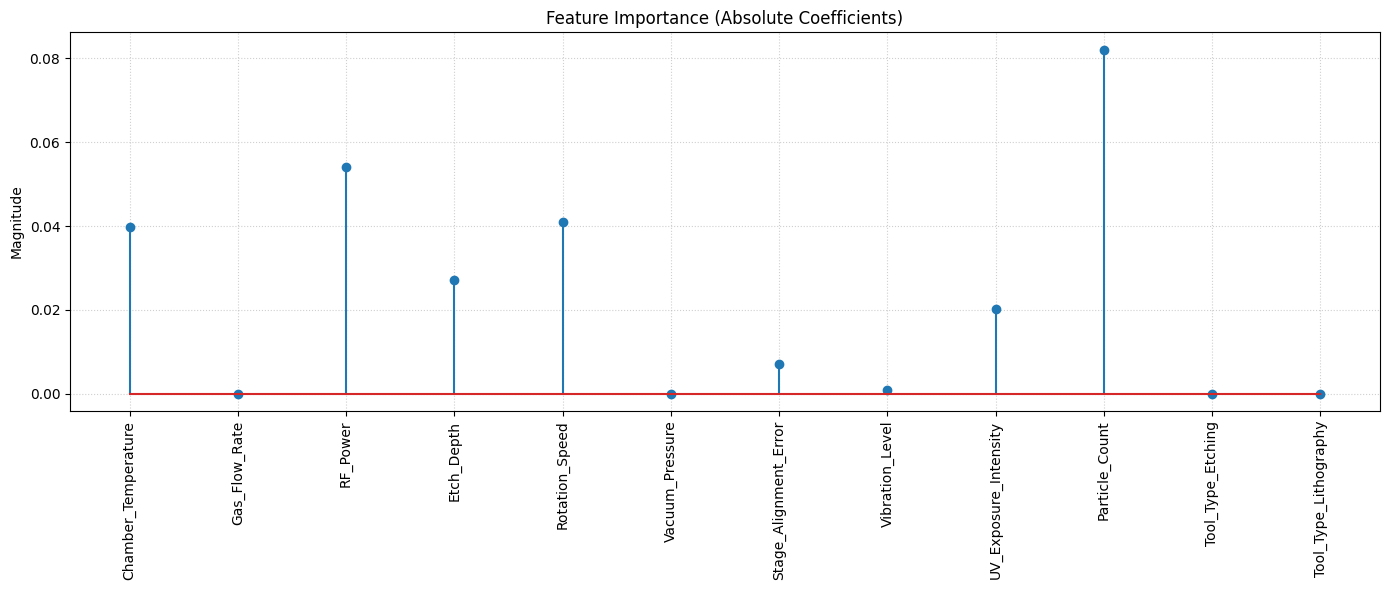

Top 5 Most Important Features -
Particle_Count = -0.0821
RF_Power = -0.0542
Rotation_Speed = -0.0409
Chamber_Temperature = 0.0397
Etch_Depth = 0.0272


In [4]:
model_eda = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', class_weight='balanced', random_state=1)
model_eda.fit(x_train, y_train)
theta_star = model_eda.coef_[0]
feature_names = x.columns

plt.figure(figsize=(14, 6))
plt.stem(np.abs(theta_star))
plt.xticks(range(len(feature_names)), feature_names, rotation=90, fontsize=10)
plt.title('Feature Importance (Absolute Coefficients)')
plt.ylabel('Magnitude')
plt.grid(linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features -")
top_indices = np.argsort(np.abs(theta_star))[::-1][:5]
for i in top_indices:
    print(f"{feature_names[i]} = {theta_star[i]:.4f}")


# 4. Baseline Modeling
## 4.1 Vanilla Logistic Regression


In [5]:
model = LogisticRegression(class_weight='balanced', C=1.0, max_iter=5000, random_state=RANDOM_STATE)
model.fit(x_train, y_train)
print('Vanilla Model Trained!')


Vanilla Model Trained!


## 4.2 Cross Validation Evaluation


In [6]:
pipeline = Pipeline([('scaler', StandardScaler()),('classifier', LogisticRegression(class_weight='balanced', C=1.0, max_iter=5000, random_state=RANDOM_STATE))])

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
f2_scorer = make_scorer(fbeta_score, beta=2)
scoring = {'recall': 'recall','precision': 'precision','f1': 'f1','accuracy': 'accuracy','f2': f2_scorer}
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring, return_train_score=False)

print(f"{'Fold':<6} {'Recall':<10} {'F2 Score':<10} {'Precision':<10} {'F1':<10} {'Accuracy':<10}")
print("-" * 65)
for i in range(4):
    print(f"{i+1:<6} {scores['test_recall'][i]:<10.4f} {scores['test_f2'][i]:<10.4f} {scores['test_precision'][i]:<10.4f} {scores['test_f1'][i]:<10.4f} {scores['test_accuracy'][i]:<10.4f}")
print("-" * 65)
print(f"Mean Recall: {np.mean(scores['test_recall']):.4f}")
print(f"Mean F2:     {np.mean(scores['test_f2']):.4f}")


Fold   Recall     F2 Score   Precision  F1         Accuracy  
-----------------------------------------------------------------
1      0.4805     0.3327     0.1492     0.2277     0.5242    
2      0.4416     0.3083     0.1396     0.2122     0.5213    
3      0.4323     0.3034     0.1384     0.2097     0.5213    
4      0.4870     0.3345     0.1485     0.2276     0.5171    
-----------------------------------------------------------------
Mean Recall: 0.4603
Mean F2:     0.3197


# 5. Regularization Analysis
## 5.1 Grid Search over L1/L2 and C values


In [7]:
penalties = ['l1', 'l2']
C_values = np.logspace(-5, 5, 10)
results = []

print(f"{'Penalty':<10} {'C':<12} {'F2':<10} {'Recall':<12}")
print("-" * 50)

for penalty in penalties:
    for C in C_values:
        solver = 'liblinear'
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(
                penalty=penalty,
                C=C,
                solver=solver,
                class_weight='balanced',
                max_iter=5000,
                random_state=RANDOM_STATE
            ))
        ])

        cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=RANDOM_STATE)
        f2_scores = cross_val_score(pipeline, x, y, cv=cv, scoring=f2_scorer)
        rec_scores = cross_val_score(pipeline, x, y, cv=cv, scoring='recall')

        mean_f2 = np.mean(f2_scores)
        mean_rec = np.mean(rec_scores)

        results.append({'Penalty': penalty, 'C': C, 'F2': mean_f2, 'Recall': mean_rec})
        print(f"{penalty:<10} {C:<12.5f} {mean_f2:<10.4f} {mean_rec:<12.4f}")

results_df = pd.DataFrame(results)


Penalty    C            F2         Recall      
--------------------------------------------------
l1         0.00001      0.0000     0.0000      
l1         0.00013      0.0000     0.0000      
l1         0.00167      0.0000     0.0000      
l1         0.02154      0.3366     0.4959      
l1         0.27826      0.3286     0.4782      
l1         3.59381      0.3185     0.4587      
l1         46.41589     0.3197     0.4603      
l1         599.48425    0.3197     0.4603      
l1         7742.63683   0.3197     0.4603      
l1         100000.00000 0.3197     0.4603      
l2         0.00001      0.3316     0.4863      
l2         0.00013      0.3299     0.4830      
l2         0.00167      0.3308     0.4814      
l2         0.02154      0.3204     0.4620      
l2         0.27826      0.3198     0.4603      
l2         3.59381      0.3197     0.4603      
l2         46.41589     0.3197     0.4603      
l2         599.48425    0.3197     0.4603      
l2         7742.63683   0.3197     0.

## 5.2 Regularization Impact Visualization


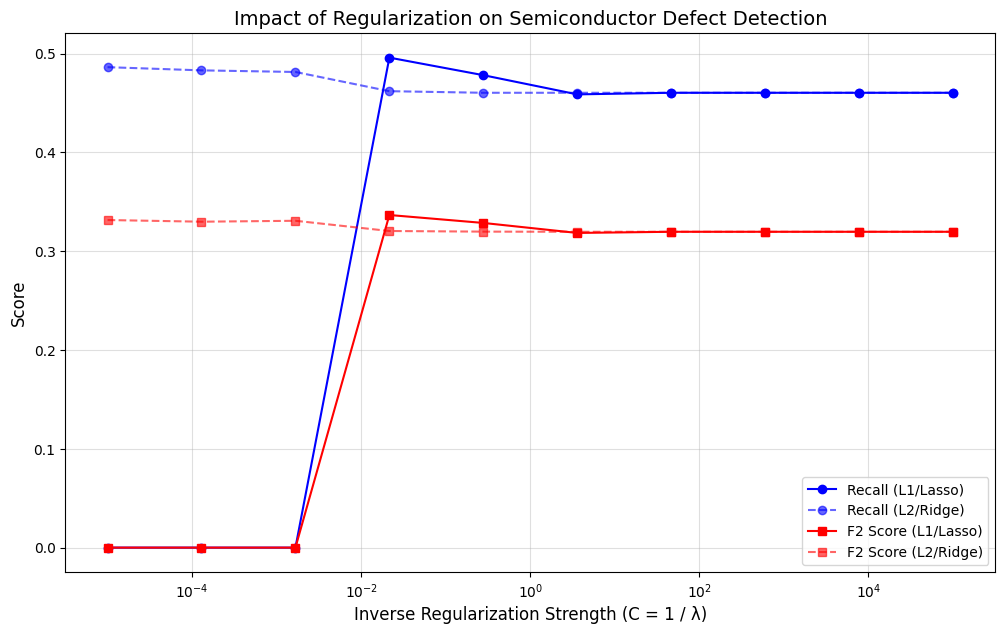

In [8]:
plt.figure(figsize=(12, 7))

df_l1 = results_df[results_df['Penalty'] == 'l1']
df_l2 = results_df[results_df['Penalty'] == 'l2']

plt.plot(df_l1['C'], df_l1['Recall'], label='Recall (L1/Lasso)', color='blue', marker='o', linestyle='-')
plt.plot(df_l2['C'], df_l2['Recall'], label='Recall (L2/Ridge)', color='blue', marker='o', linestyle='--', alpha=0.6)
plt.plot(df_l1['C'], df_l1['F2'], label='F2 Score (L1/Lasso)', color='red', marker='s', linestyle='-')
plt.plot(df_l2['C'], df_l2['F2'], label='F2 Score (L2/Ridge)', color='red', marker='s', linestyle='--', alpha=0.6)

plt.xscale('log')
plt.xlabel('Inverse Regularization Strength (C = 1 / λ)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Impact of Regularization on Semiconductor Defect Detection', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.show()


We can compare in the above plot, L1 (Lasso) and L2 (Ridge) regularizations across different values of C (Inverse of regularization strengths, so lower C means stronger regularization). 

## 5.3 Regularization Path (L1)


Running regularization path...
Best C: 0.0281 | Best F2: 0.3443


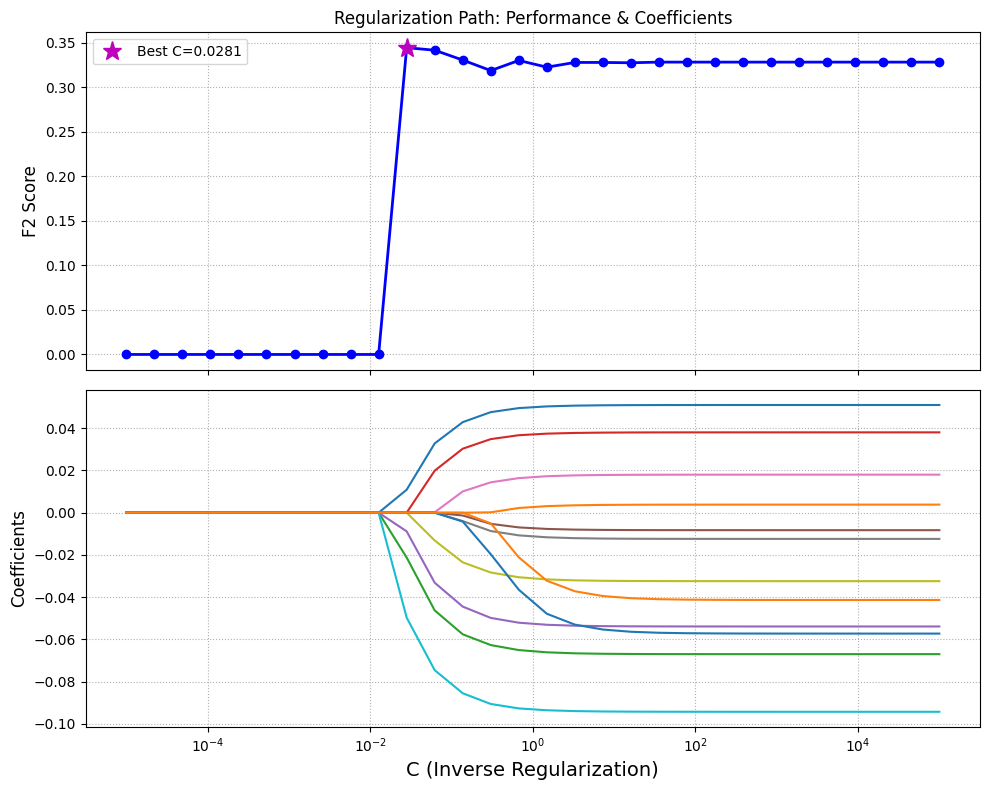

In [9]:
Cs = np.logspace(-5, 5, 30)
coefs = []
f2_scores = []
print("Running regularization path...")

for C in Cs:
    model = LogisticRegression(penalty='l1', C=C, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
    model.fit(x_train, y_train)
    coefs.append(model.coef_[0])
    y_pred = model.predict(x_test)
    f2_scores.append(fbeta_score(y_test, y_pred, beta=2))

coefs = np.array(coefs)
f2_scores = np.array(f2_scores)
best_idx = np.argmax(f2_scores)
best_C = Cs[best_idx]
best_f2 = f2_scores[best_idx]

print(f"Best C: {best_C:.4f} | Best F2: {best_f2:.4f}")

fig, ax = plt.subplots(figsize=(10, 8), nrows=2, sharex=True)
ax[0].semilogx(Cs, f2_scores, 'o-', color='b', linewidth=2)
ax[0].semilogx(best_C, best_f2, '*', color='m', markersize=14, label=f'Best C={best_C:.4f}')
ax[0].set_ylabel('F2 Score', fontsize=12)
ax[0].grid(linestyle=':')
ax[0].legend()
ax[0].set_title('Regularization Path: Performance & Coefficients')

ax[1].semilogx(Cs, coefs)
ax[1].set_xlabel('C (Inverse Regularization)', fontsize=14)
ax[1].set_ylabel('Coefficients', fontsize=12)
ax[1].grid(linestyle=':')
plt.tight_layout()
plt.show()


 At low C (heavy regularization), L1 pushes most coefficients to zero. As C increases, the penalty weakens and coefficients are allowed to grow. The top panel shows F2 score at each C value we pick the C that gives the best F2.

# 6.1.1 Threshold Tuning - This sucks btw!


In [65]:
from sklearn.model_selection import TunedThresholdClassifierCV
f2_scorer = make_scorer(fbeta_score, beta=2)
balanced_accuracy_scorer = make_scorer(lambda y_true, y_pred: (recall_score(y_true, y_pred) + precision_score(y_true, y_pred, zero_division=0)) / 2)
hybrid_scorer = make_scorer(
    lambda y_true, y_pred: (
        0.5 * fbeta_score(y_true, y_pred, beta=2) + 
        0.3 * (recall_score(y_true, y_pred) + precision_score(y_true, y_pred, zero_division=0)) / 2
    )
)
tuned_model = TunedThresholdClassifierCV(
    LogisticRegression(penalty='l1', C=best_C, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE),
    scoring=hybrid_scorer,
    cv=5
)

tuned_model.fit(x_train, y_train)

print(f"Best threshold: {tuned_model.best_threshold_:.4f}")
print(f"Best CV score:  {tuned_model.best_score_:.4f}")

# Evaluate on test
y_pred = tuned_model.predict(x_test)

print(f"\nTest Set Results:")
print(f"  MCC:       {matthews_corrcoef(y_test, y_pred):.4f}")
print(f"  F2:        {fbeta_score(y_test, y_pred, beta=2):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")

Best threshold: 0.4558
Best CV score:  0.4033

Test Set Results:
  MCC:       0.0000
  F2:        0.4603
  Recall:    1.0000
  Precision: 0.1457
  Accuracy:  0.1457


# 6.1.2 Threshold Tuning - Attempt from some article I found using different scorers, roc curve whatnot

G-mean optimal threshold: 0.5048
Youden's J optimal threshold: 0.4916

G-mean Threshold Results:
  MCC:       0.0325
  F2:        0.3253
  Recall:    0.4390
  Precision: 0.1598
  Accuracy:  0.5818

Youden's J Threshold Results:
  MCC:       0.0537
  F2:        0.4324
  Recall:    0.7642
  Precision: 0.1580
  Accuracy:  0.3720


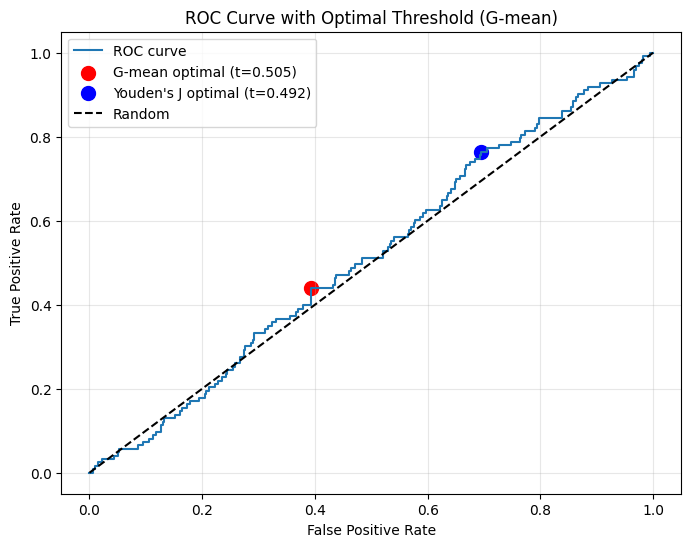

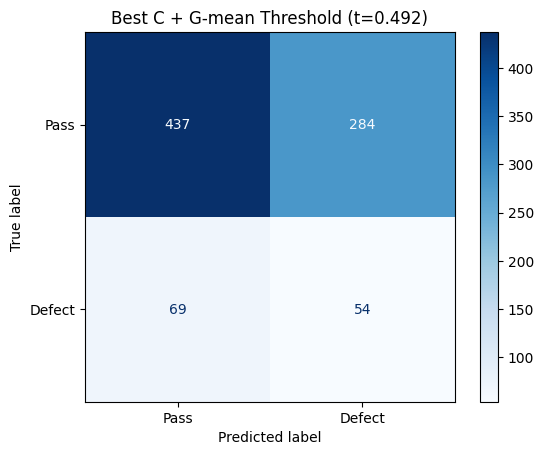

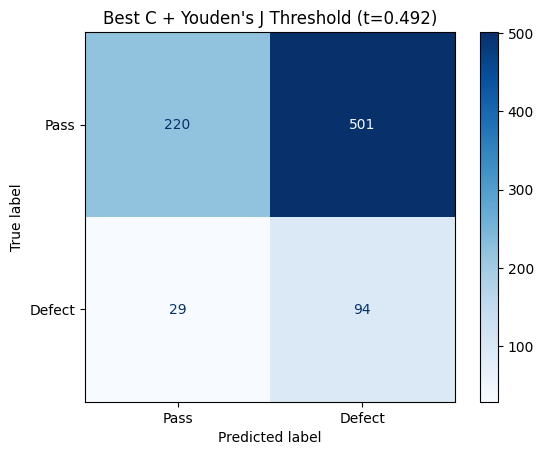

In [ ]:
# https://medium.com/data-science/optimal-threshold-for-imbalanced-classification-5884e870c293
#this is the source I referred to

from sklearn.metrics import roc_curve
best_c_model = LogisticRegression(penalty='l1', C=best_C, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
best_c_model.fit(x_train, y_train)
y_proba = best_c_model.predict_proba(x_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Method 1: G-mean (geometric mean of sensitivity and specificity)
gmean = np.sqrt(tpr * (1 - fpr))
best_idx_gmean = np.argmax(gmean)
best_thresh_gmean = thresholds[best_idx_gmean]

# Method 2: Youden's J statistic (TPR - FPR)
j_scores = tpr - fpr
best_idx_j = np.argmax(j_scores)
best_thresh_j = thresholds[best_idx_j]

print(f"G-mean optimal threshold: {best_thresh_gmean:.4f}")
print(f"Youden's J optimal threshold: {best_thresh_j:.4f}")

# Apply G-mean threshold
y_pred_gmean = (y_proba >= best_thresh_gmean).astype(int)

print(f"\nG-mean Threshold Results:")
print(f"  MCC:       {matthews_corrcoef(y_test, y_pred_gmean):.4f}")
print(f"  F2:        {fbeta_score(y_test, y_pred_gmean, beta=2):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_gmean):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_gmean, zero_division=0):.4f}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_gmean):.4f}")

y_pred_j = (y_proba >= best_thresh_j).astype(int)

print(f"\nYouden's J Threshold Results:")
print(f"  MCC:       {matthews_corrcoef(y_test, y_pred_j):.4f}")
print(f"  F2:        {fbeta_score(y_test, y_pred_j, beta=2):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_j):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_j, zero_division=0):.4f}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_j):.4f}")

# Visualize ROC with optimal point
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve')
plt.scatter(fpr[best_idx_gmean], tpr[best_idx_gmean], marker='o', color='red', s=100, label=f'G-mean optimal (t={best_thresh_gmean:.3f})')
plt.scatter(fpr[best_idx_j], tpr[best_idx_j], marker='o', color='blue', s=100, label=f'Youden\'s J optimal (t={best_thresh_j:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Optimal Threshold (G-mean)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Confusion matrix
cm_gmean = confusion_matrix(y_test, y_pred_gmean)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gmean, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Best C + G-mean Threshold (t={best_thresh_j:.3f})')
plt.grid(False)
plt.show()

cm_j = confusion_matrix(y_test, y_pred_j)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_j, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Best C + Youden\'s J Threshold (t={best_thresh_j:.3f})')
plt.grid(False)
plt.show()


# 6.2 Undersampling

C            F2         Recall    
-----------------------------------
0.000100     0.0000     0.0000    
0.000264     0.0000     0.0000    
0.000695     0.0000     0.0000    
0.001833     0.0000     0.0000    
0.004833     0.0000     0.0000    
0.012743     0.0000     0.0000    
0.033598     0.0000     0.0000    
0.088587     0.5268     0.5262    
0.233572     0.5156     0.5141    
0.615848     0.5203     0.5223    
1.623777     0.5217     0.5263    
4.281332     0.5188     0.5243    
11.288379    0.5222     0.5283    
29.763514    0.5220     0.5283    
78.475997    0.5220     0.5283    
206.913808   0.5220     0.5283    
545.559478   0.5220     0.5283    
1438.449888  0.5220     0.5283    
3792.690191  0.5220     0.5283    
10000.000000 0.5220     0.5283    

Best C (undersampled): 0.088587

Undersampled Log Reg (tuned C):
  MCC:       0.0098
  F2:        0.3502
  Recall:    0.5285
  Precision: 0.1491


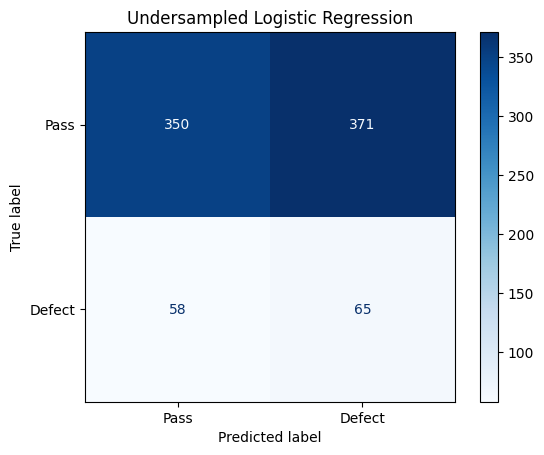

Best threshold: 0.4167
Best CV score:  0.8336

Undersampled + Threshold Tuned:
  MCC:       0.0000
  F2:        0.4603
  Recall:    1.0000
  Precision: 0.1457
  Accuracy:  0.1457


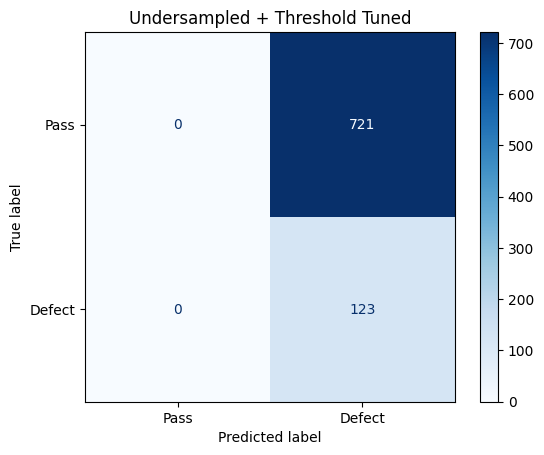

G-mean optimal threshold: 0.4972
Youden's J optimal threshold: 0.4958

Optimal Threshold Results:
  MCC:       0.0643
  F2:        0.4054
  Recall:    0.6341
  Precision: 0.1660


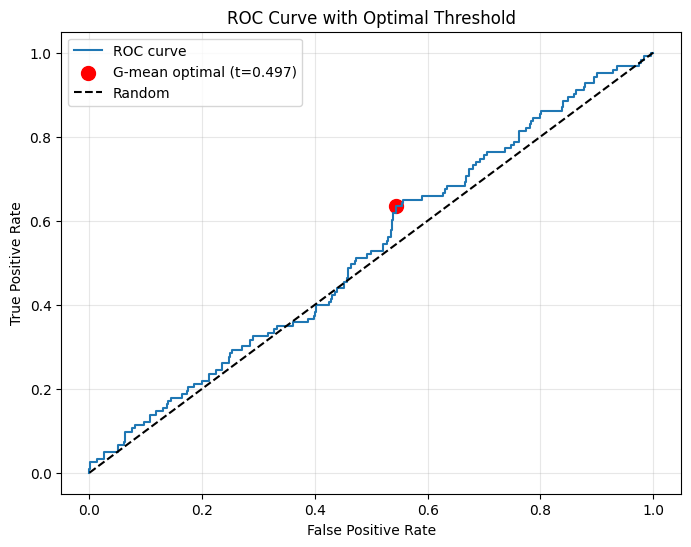

Text(0.5, 1.0, 'Undersampled + Threshold Optimized')

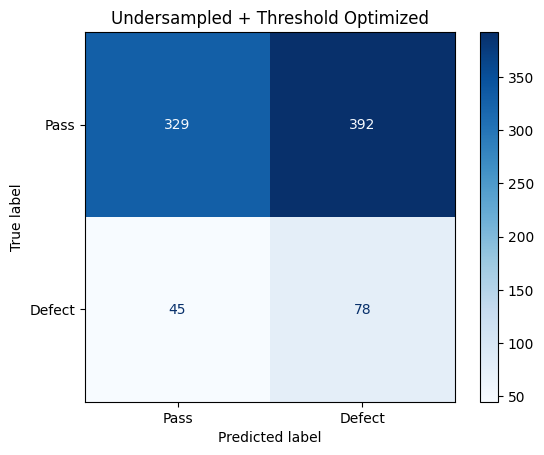

In [ ]:
minority_idx = y_train[y_train == 1].index
majority_idx = y_train[y_train == 0].sample(n=len(minority_idx), random_state=RANDOM_STATE).index
balanced_idx = minority_idx.union(majority_idx)

x_train_under = x_train.loc[balanced_idx]
y_train_under = y_train.loc[balanced_idx]
# Re-tune C on undersampled data
C_values = np.logspace(-4, 4, 20)
results_under = []

print(f"{'C':<12} {'F2':<10} {'Recall':<10}")
print("-" * 35)

for C in C_values:
    model = LogisticRegression(penalty='l1', C=C, solver='liblinear', random_state=RANDOM_STATE)
    
    # CV on undersampled data
    f2_scores = cross_val_score(model, x_train_under, y_train_under, cv=4, scoring=f2_scorer)
    rec_scores = cross_val_score(model, x_train_under, y_train_under, cv=4, scoring='recall')
    
    mean_f2 = np.mean(f2_scores)
    mean_rec = np.mean(rec_scores)
    results_under.append({'C': C, 'F2': mean_f2, 'Recall': mean_rec})
    print(f"{C:<12.6f} {mean_f2:<10.4f} {mean_rec:<10.4f}")

best_C_under = max(results_under, key=lambda x: x['F2'])['C']
print(f"\nBest C (undersampled): {best_C_under:.6f}")
model_under = LogisticRegression(penalty='l1', C=best_C_under, solver='liblinear', random_state=RANDOM_STATE)
model_under.fit(x_train_under, y_train_under)

y_pred_under = model_under.predict(x_test)

print(f"\nUndersampled Log Reg (tuned C):")
print(f"  MCC:       {matthews_corrcoef(y_test, y_pred_under):.4f}")
print(f"  F2:        {fbeta_score(y_test, y_pred_under, beta=2):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_under):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_under, zero_division=0):.4f}")
cm = confusion_matrix(y_test, y_pred_under)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Undersampled Logistic Regression')
plt.grid(False)
plt.show()
tuned_model_under = TunedThresholdClassifierCV(
    LogisticRegression(penalty='l1', C=best_C_under, solver='liblinear', random_state=RANDOM_STATE),
    scoring=f2_scorer,
    cv=5
)

tuned_model_under.fit(x_train_under, y_train_under)

print(f"Best threshold: {tuned_model_under.best_threshold_:.4f}")
print(f"Best CV score:  {tuned_model_under.best_score_:.4f}")

# Evaluate on original test set
y_pred_tuned_under = tuned_model.predict(x_test)

print(f"\nUndersampled + Threshold Tuned:")
print(f"  MCC:       {matthews_corrcoef(y_test, y_pred_tuned_under):.4f}")
print(f"  F2:        {fbeta_score(y_test, y_pred_tuned_under, beta=2):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_tuned_under):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_tuned_under, zero_division=0):.4f}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_tuned_under):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned_under)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Undersampled + Threshold Tuned')
plt.grid(False)
plt.show()

from sklearn.metrics import roc_curve

# Get probabilities
y_proba = model_under.predict_proba(x_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Method 1: G-mean
gmean = np.sqrt(tpr * (1 - fpr))
best_idx_gmean = np.argmax(gmean)
best_thresh_gmean = thresholds[best_idx_gmean]

# Method 2: Youden's J
j_scores = tpr - fpr
best_idx_j = np.argmax(j_scores)
best_thresh_j = thresholds[best_idx_j]

print(f"G-mean optimal threshold: {best_thresh_gmean:.4f}")
print(f"Youden's J optimal threshold: {best_thresh_j:.4f}")

# Apply best threshold (they often give same result)
y_pred_optimal = (y_proba >= best_thresh_gmean).astype(int)

print(f"\nOptimal Threshold Results:")
print(f"  MCC:       {matthews_corrcoef(y_test, y_pred_optimal):.4f}")
print(f"  F2:        {fbeta_score(y_test, y_pred_optimal, beta=2):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_optimal, zero_division=0):.4f}")

# Visualize
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve')
plt.scatter(fpr[best_idx_gmean], tpr[best_idx_gmean], marker='o', color='red', s=100, label=f'G-mean optimal (t={best_thresh_gmean:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Optimal Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

cm = confusion_matrix(y_test, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Undersampled + Threshold Optimized')

# 7. Model Comparison

### Matthews Correlation Coefficient (MCC)

MCC is a metric that accounts for all four quadrants of the confusion matrix, making it robust to class imbalance. Unlike accuracy or recall alone, MCC only gives a high score when the model performs well on **both** positive and negative classes.

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

Where TP = True Positives, TN = True Negatives, FP = False Positives, FN = False Negatives.

**Interpretation:**
- **+1**: Perfect prediction
- **0**: No better than random guessing
- **-1**: Complete disagreement (predictions are inverted)

MCC is particularly useful here because a model that predicts all samples as "Defect" would achieve high recall but MCC ≈ 0, exposing the lack of true predictive power.


In [59]:
# 1. Vanilla (C=1.0, threshold=0.5)
vanilla_model = LogisticRegression(class_weight='balanced', C=1.0, max_iter=5000, random_state=RANDOM_STATE)
vanilla_model.fit(x_train, y_train)
vanilla_probs = vanilla_model.predict_proba(x_test)[:, 1]
vanilla_preds = (vanilla_probs >= 0.5).astype(int)

# 2. Best C (L1, tuned C, threshold=0.5)
best_c_model = LogisticRegression(penalty='l1', C=best_C, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
best_c_model.fit(x_train, y_train)
best_c_probs = best_c_model.predict_proba(x_test)[:, 1]
best_c_preds = (best_c_probs >= 0.5).astype(int)

# 3. Best C + Threshold tuning
best_thresh_preds = (best_c_probs >= tuned_model.best_threshold_).astype(int)

def get_metrics(y_true, y_pred):
    return {
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F2': fbeta_score(y_true, y_pred, beta=2),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
    }

comparison = pd.DataFrame({
    'Vanilla (C=1.0, t=0.5)': get_metrics(y_test, vanilla_preds),
    f'Best C={best_C:.4f}, t=0.5': get_metrics(y_test, best_c_preds),
    f'Best C + t={tuned_model.best_threshold_:.2f}': get_metrics(y_test, best_thresh_preds)
}).T

print(comparison.round(4).to_string())


                           MCC  Recall      F2  Accuracy  Precision
Vanilla (C=1.0, t=0.5)  0.0039  0.4715  0.3273    0.5249     0.1472
Best C=0.0281, t=0.5    0.0091  0.5122  0.3443    0.5024     0.1489
Best C + t=0.46         0.0000  1.0000  0.4603    0.1457     0.1457


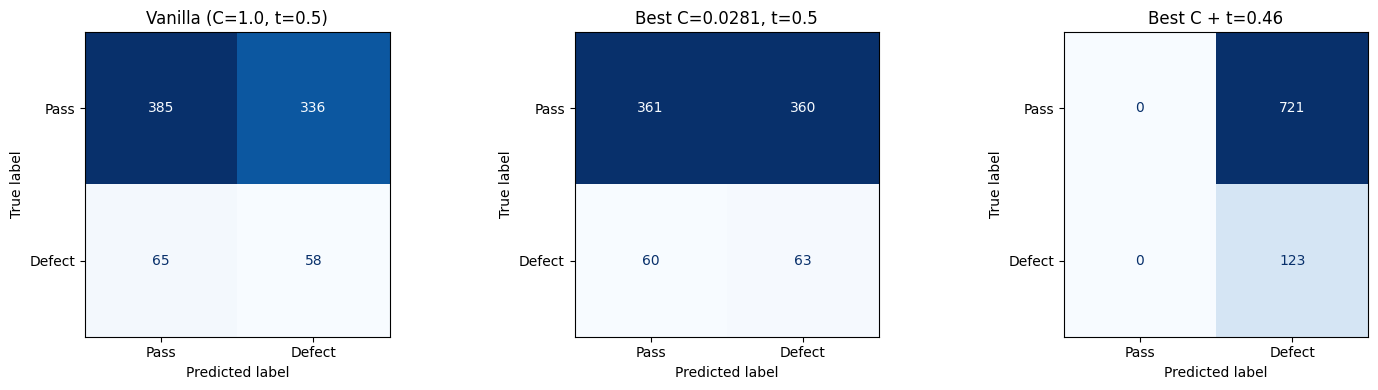

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Vanilla (C=1.0, t=0.5)', f'Best C={best_C:.4f}, t=0.5', f'Best C + t={tuned_model.best_threshold_:.2f}']
preds_list = [vanilla_preds, best_c_preds, best_thresh_preds]

for ax, preds, title in zip(axes, preds_list, titles):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(title)
    ax.grid(False)

plt.tight_layout()
plt.show()


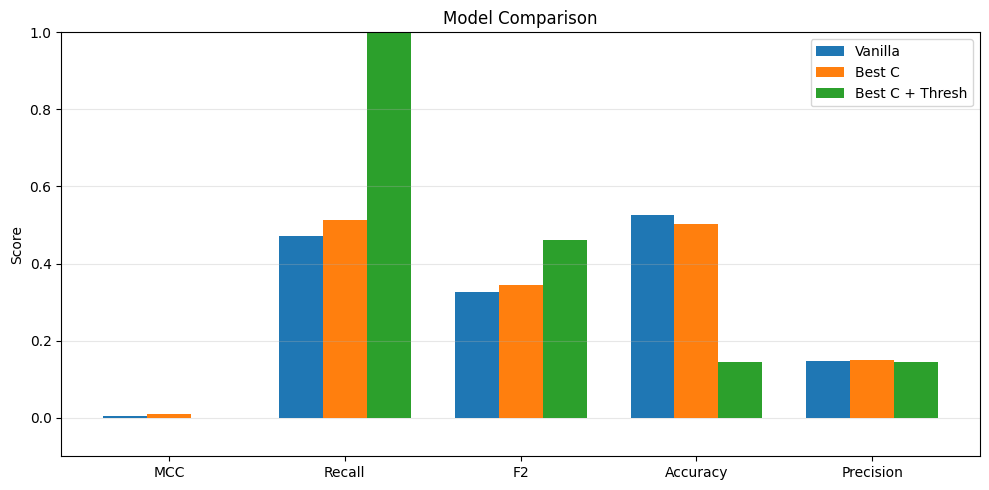

In [97]:
metrics = ['MCC', 'Recall', 'F2', 'Accuracy', 'Precision', ]
x_pos = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - width, comparison.iloc[0], width, label='Vanilla')
ax.bar(x_pos, comparison.iloc[1], width, label='Best C')
ax.bar(x_pos + width, comparison.iloc[2], width, label='Best C + Thresh')

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
ax.set_ylim(-0.1, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


The low MCC score across all models indicates that while the models perform well on metrics like Recall and F2 Score, they struggle with overall balanced classification performance. This suggests that the models may be biased towards one class depending on how the model is tuned, leading to either a high number of false positives or false negatives. Hence, logistic regression, even with tuning, may not be sufficient for this imbalanced classification task, and we will move on to exploring more advanced models to achieve better performance. 

NOW FOR SUPPORT VECTOR MACHINES - 
# 8. SVM Baseline Modeling

Main function of SVMs is to find a hyperplane that separates classes with maximum margin. The hyperparameters we will search over are -
- **C** - Regularization Strength (Inverse)
- **Kernel** - linear, RBF (radial basis function), or polynomial
- **Gamma** - (for RBF/poly): Controls decision boundary flexibility


## 8.1 Vanilla SVM Model Training


In [84]:
svm_linear = SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE)
svm_linear.fit(x_train, y_train)
y_pred_svm = svm_linear.predict(x_test)
print("Vanilla SVM Model Trained!")

print("SVM Linear Baseline:")
print(f"  MCC:       {matthews_corrcoef(y_test, y_pred_svm):.4f}")
print(f"  F2:        {fbeta_score(y_test, y_pred_svm, beta=2):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")

Vanilla SVM Model Trained!
SVM Linear Baseline:
  MCC:       0.0196
  F2:        0.3540
  Recall:    0.5285
  Precision: 0.1526
  Accuracy:  0.5036



## 8.2 Cross-Validation Evaluation

In [88]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
scoring = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'accuracy': 'accuracy', 'f2': f2_scorer}
scores_svm = cross_validate(svm_pipeline, x, y, cv=cv, scoring=scoring, return_train_score=False)

print(f"{'Fold':<6} {'Recall':<10} {'F2 Score':<10} {'Precision':<10} {'F1':<10} {'Accuracy':<10}")
print("-" * 65)
for i in range(4):
    print(f"{i+1:<6} {scores_svm['test_recall'][i]:<10.4f} {scores_svm['test_f2'][i]:<10.4f} {scores_svm['test_precision'][i]:<10.4f} {scores_svm['test_f1'][i]:<10.4f} {scores_svm['test_accuracy'][i]:<10.4f}")
print("-" * 65)
print(f"Mean Recall: {np.mean(scores_svm['test_recall']):.4f}")
print(f"Mean F2:     {np.mean(scores_svm['test_f2']):.4f}")
print(f"Mean Precision: {np.mean(scores_svm['test_precision']):.4f}")
print(f"Mean Accuracy:     {np.mean(scores_svm['test_accuracy']):.4f}")

Fold   Recall     F2 Score   Precision  F1         Accuracy  
-----------------------------------------------------------------
1      0.4805     0.3318     0.1483     0.2266     0.5213    
2      0.5065     0.3427     0.1494     0.2308     0.5071    
3      0.4774     0.3324     0.1501     0.2284     0.5261    
4      0.4935     0.3333     0.1450     0.2242     0.5009    
-----------------------------------------------------------------
Mean Recall: 0.4895
Mean F2:     0.3351
Mean Precision: 0.1482
Mean Accuracy:     0.5139


## 8.3 Hyperparameter Grid Search (Across Kernel, C and gamma for RBF and Polynomial kernel)

### 8.3.1 Linear Kernel

In [89]:
C_values = np.logspace(-2, 2, 5)
gamma_values = np.logspace(-2, 2, 5)
results_svm = []

print(f"{'Kernel':<10} {'C':<10} {'Gamma':<12} {'F2':<10} {'Recall':<10}")
print("-" * 55)

# Linear kernel (no gamma)
for C in C_values:
    svm_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel='linear', C=C, class_weight='balanced', random_state=RANDOM_STATE))
    ])
    
    f2_scores = cross_val_score(svm_pipe, x, y, cv=cv, scoring=f2_scorer)
    rec_scores = cross_val_score(svm_pipe, x, y, cv=cv, scoring='recall')
    
    results_svm.append({'Kernel': 'linear', 'C': C, 'Gamma': None, 'F2': np.mean(f2_scores), 'Recall': np.mean(rec_scores)})
    print(f"{'linear':<10} {C:<10.4f} {'N/A':<12} {np.mean(f2_scores):<10.4f} {np.mean(rec_scores):<10.4f}")



Kernel     C          Gamma        F2         Recall    
-------------------------------------------------------
linear     0.0100     N/A          0.3381     0.4976    
linear     0.1000     N/A          0.3332     0.4862    
linear     1.0000     N/A          0.3351     0.4895    
linear     10.0000    N/A          0.3360     0.4911    
linear     100.0000   N/A          0.3358     0.4911    


### 8.3.3 RBF Kernel

In [90]:
# RBF kernel
for C in C_values:
    for gamma in gamma_values:
        svm_pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced', random_state=RANDOM_STATE))
        ])
        
        f2_scores = cross_val_score(svm_pipe, x, y, cv=cv, scoring=f2_scorer)
        rec_scores = cross_val_score(svm_pipe, x, y, cv=cv, scoring='recall')
        
        results_svm.append({'Kernel': 'rbf', 'C': C, 'Gamma': gamma, 'F2': np.mean(f2_scores), 'Recall': np.mean(rec_scores)})
        print(f"{'rbf':<10} {C:<10.4f} {gamma:<12.4f} {np.mean(f2_scores):<10.4f} {np.mean(rec_scores):<10.4f}")

results_svm_df = pd.DataFrame(results_svm)

rbf        0.0100     0.0100       0.3461     0.7500    
rbf        0.0100     0.1000       0.3461     0.7500    
rbf        0.0100     1.0000       0.3461     0.7500    
rbf        0.0100     10.0000      0.3461     0.7500    
rbf        0.0100     100.0000     0.3461     0.7500    
rbf        0.1000     0.0100       0.3481     0.5414    
rbf        0.1000     0.1000       0.3167     0.4311    
rbf        0.1000     1.0000       0.4613     1.0000    
rbf        0.1000     10.0000      0.4613     1.0000    
rbf        0.1000     100.0000     0.4613     1.0000    
rbf        1.0000     0.0100       0.3426     0.5138    
rbf        1.0000     0.1000       0.2902     0.3760    
rbf        1.0000     1.0000       0.0000     0.0000    
rbf        1.0000     10.0000      0.0000     0.0000    
rbf        1.0000     100.0000     0.0000     0.0000    
rbf        10.0000    0.0100       0.3348     0.4960    
rbf        10.0000    0.1000       0.2034     0.2269    
rbf        10.0000    1.0000   

Best valid RBF: Kernel         rbf
C              0.1
Gamma         0.01
F2        0.348085
Recall    0.541412
Name: 10, dtype: object
Best Linear: C=0.0100, F2=0.3381
Best RBF: C=0.1000, Gamma=0.0100, F2=0.3481


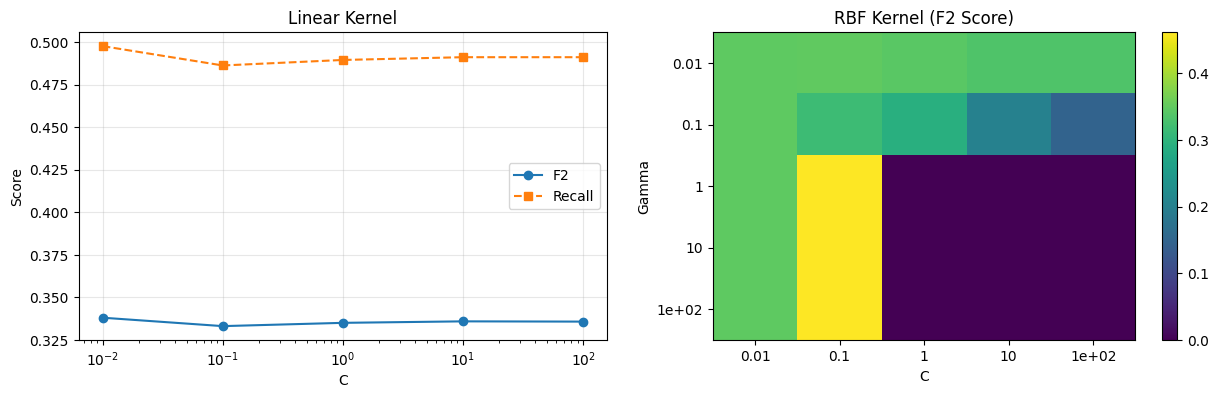

In [27]:
best_linear = results_svm_df[results_svm_df['Kernel'] == 'linear'].loc[results_svm_df[results_svm_df['Kernel'] == 'linear']['F2'].idxmax()]
valid_rbf = results_svm_df[(results_svm_df['Kernel'] == 'rbf') & 
                            (results_svm_df['Recall'] > 0.1) & 
                            (results_svm_df['Recall'] < 0.95)]
best_rbf = valid_rbf.loc[valid_rbf['F2'].idxmax()]
print("Best valid RBF:", best_rbf)

print("Best Linear:", f"C={best_linear['C']:.4f}, F2={best_linear['F2']:.4f}")
print("Best RBF:", f"C={best_rbf['C']:.4f}, Gamma={best_rbf['Gamma']:.4f}, F2={best_rbf['F2']:.4f}")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Linear - just C vs F2
df_linear = results_svm_df[results_svm_df['Kernel'] == 'linear']
axes[0].semilogx(df_linear['C'], df_linear['F2'], 'o-', label='F2')
axes[0].semilogx(df_linear['C'], df_linear['Recall'], 's--', label='Recall')
axes[0].set_xlabel('C')
axes[0].set_ylabel('Score')
axes[0].set_title('Linear Kernel')
axes[0].legend()
axes[0].grid(alpha=0.3)

# RBF - heatmap of C vs Gamma
df_rbf = results_svm_df[results_svm_df['Kernel'] == 'rbf']
pivot_rbf = df_rbf.pivot(index='Gamma', columns='C', values='F2')
im1 = axes[1].imshow(pivot_rbf.values, aspect='auto', cmap='viridis')
axes[1].set_xticks(range(len(pivot_rbf.columns)))
axes[1].set_xticklabels([f'{c:.2g}' for c in pivot_rbf.columns])
axes[1].set_yticks(range(len(pivot_rbf.index)))
axes[1].set_yticklabels([f'{g:.2g}' for g in pivot_rbf.index])
axes[1].set_xlabel('C')
axes[1].set_ylabel('Gamma')
axes[1].set_title('RBF Kernel (F2 Score)')
plt.colorbar(im1, ax=axes[1])

           MCC  Recall      F2  Accuracy  Precision
Linear  0.0312  0.5366  0.3614    0.5118     0.1568
RBF    -0.0046  0.5122  0.3391    0.4858     0.1442


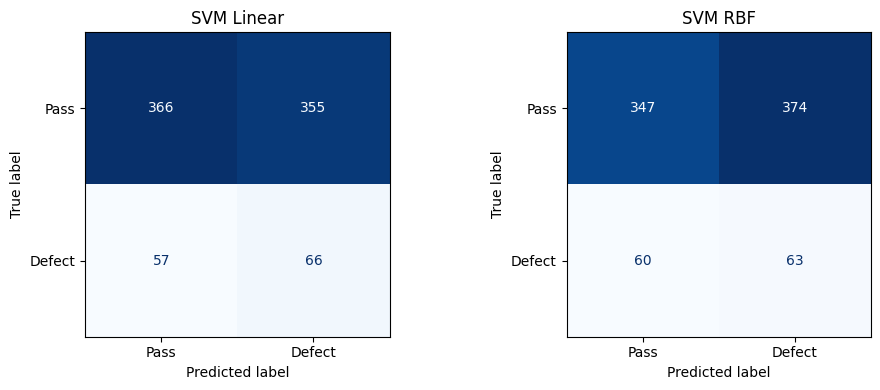

In [98]:
svm_best_linear = SVC(kernel='linear', C=best_linear['C'], class_weight='balanced', random_state=RANDOM_STATE)
svm_best_linear.fit(x_train, y_train)
pred_linear = svm_best_linear.predict(x_test)

# Best RBF
svm_best_rbf = SVC(kernel='rbf', C=best_rbf['C'], gamma=best_rbf['Gamma'], class_weight='balanced', random_state=RANDOM_STATE)
svm_best_rbf.fit(x_train, y_train)
pred_rbf = svm_best_rbf.predict(x_test)

# Metrics comparison
def get_metrics_svm(y_true, y_pred):
    return {
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F2': fbeta_score(y_true, y_pred, beta=2),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
    }

comparison_svm = pd.DataFrame({
    'Linear': get_metrics_svm(y_test, pred_linear),
    'RBF': get_metrics_svm(y_test, pred_rbf)
}).T

print(comparison_svm.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, pred, title in zip(axes, [pred_linear, pred_rbf], ['Linear', 'RBF']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(f'SVM {title}')
    ax.grid(False)

plt.tight_layout()
plt.show()

Since SVM with Linear Kernel performed better - 

Undersampled: {np.int64(0): np.int64(494), np.int64(1): np.int64(494)}
C            F2         Recall     MCC       
---------------------------------------------
0.0010       0.4161     0.5000     0.0000    
0.0027       0.4878     0.5543     0.0191    
0.0072       0.5422     0.5506     0.0304    
0.0193       0.5320     0.5385     0.0160    
0.0518       0.5242     0.5284     0.0182    
0.1389       0.5337     0.5405     0.0201    
0.3728       0.5336     0.5405     0.0181    
1.0000       0.5319     0.5385     0.0161    
2.6827       0.5301     0.5364     0.0141    
7.1969       0.5355     0.5425     0.0201    
19.3070      0.5387     0.5466     0.0201    
51.7947      0.5387     0.5466     0.0201    
138.9495     0.5387     0.5466     0.0201    
372.7594     0.5369     0.5446     0.0181    
1000.0000    0.5312     0.5385     0.0100    

Best C (by MCC): 0.0072
SVM Linear (Undersampled, C=0.0072):
  MCC:       0.0362
  F2:        0.3842
  Recall:    0.6016
  Precision: 0.1571
  Acc

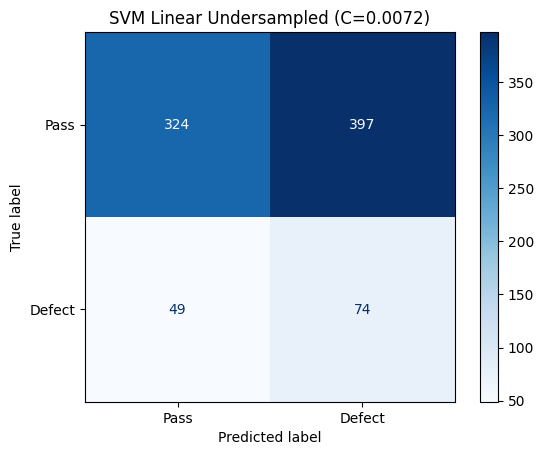

In [106]:
minority_idx = y_train[y_train == 1].index
majority_idx = y_train[y_train == 0].sample(n=len(minority_idx), random_state=RANDOM_STATE).index
balanced_idx = minority_idx.union(majority_idx)

x_train_under = x_train.loc[balanced_idx]
y_train_under = y_train.loc[balanced_idx]

print(f"Undersampled: {dict(zip(*np.unique(y_train_under, return_counts=True)))}")
C_values = np.logspace(-3, 3, 15)
results_svm_under = []

print(f"{'C':<12} {'F2':<10} {'Recall':<10} {'MCC':<10}")
print("-" * 45)

for C in C_values:
    svm = SVC(kernel='linear', C=C, random_state=RANDOM_STATE)
    
    f2_scores = cross_val_score(svm, x_train_under, y_train_under, cv=4, scoring=f2_scorer)
    rec_scores = cross_val_score(svm, x_train_under, y_train_under, cv=4, scoring='recall')
    mcc_scorer = make_scorer(matthews_corrcoef)
    mcc_scores = cross_val_score(svm, x_train_under, y_train_under, cv=4, scoring=mcc_scorer)
    
    results_svm_under.append({
        'C': C, 
        'F2': np.mean(f2_scores), 
        'Recall': np.mean(rec_scores),
        'MCC': np.mean(mcc_scores)
    })
    print(f"{C:<12.4f} {np.mean(f2_scores):<10.4f} {np.mean(rec_scores):<10.4f} {np.mean(mcc_scores):<10.4f}")

results_svm_under_df = pd.DataFrame(results_svm_under)
best_C_svm = results_svm_under_df.loc[results_svm_under_df['MCC'].idxmax(), 'C']
print(f"\nBest C (by MCC): {best_C_svm:.4f}")
svm_best = SVC(kernel='linear', C=20, random_state=RANDOM_STATE)
svm_best.fit(x_train_under, y_train_under)
y_pred_svm_best = svm_best.predict(x_test)

print(f"SVM Linear (Undersampled, C={best_C_svm:.4f}):")
print(f"  MCC:       {matthews_corrcoef(y_test, y_pred_svm_best):.4f}")
print(f"  F2:        {fbeta_score(y_test, y_pred_svm_best, beta=2):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_svm_best):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_svm_best, zero_division=0):.4f}")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_svm_best):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'SVM Linear Undersampled (C={best_C_svm:.4f})')
plt.grid(False)
plt.show()

## 8.4 Polynomial Kernel Tests
These take a long time so we kept our C and gamma search grids smaller (based on results we saw from previous models)

In [ ]:
print(f"{'Degree':<8} {'C':<8} {'Gamma':<10} {'MCC':<10} {'F2':<10} {'Recall':<10}")
print("-" * 60)

poly_results = []
for degree in [2, 3]:
    for C in [0.01, 0.1, 1.0]:
        for gamma in [0.01, 0.1, 1.0]:
            svm_poly = SVC(kernel='poly', degree=degree, C=C, gamma=gamma, class_weight='balanced', random_state=RANDOM_STATE)
            svm_poly.fit(x_train, y_train)
            pred = svm_poly.predict(x_test)
            mcc = matthews_corrcoef(y_test, pred)
            f2 = fbeta_score(y_test, pred, beta=2)
            rec = recall_score(y_test, pred)
            poly_results.append({'Degree': degree, 'C': C, 'Gamma': gamma, 'MCC': mcc, 'F2': f2, 'Recall': rec})
            print(f"{degree:<8} {C:<8} {gamma:<10} {mcc:<10.4f} {f2:<10.4f} {rec:<10.4f}")

poly_df = pd.DataFrame(poly_results)
best_poly = poly_df.loc[poly_df['MCC'].idxmax()]
print(f"\nBest Poly: degree={int(best_poly['Degree'])}, C={best_poly['C']}, gamma={best_poly['Gamma']}, MCC={best_poly['MCC']:.4f}")


Degree   C        Gamma      MCC        F2         Recall    
------------------------------------------------------------
2        0.01     0.01       0.0000     0.0000     0.0000    
2        0.01     0.1        -0.0142    0.0000     0.0000    
2        0.01     1.0        -0.0159    0.3261     0.4878    
2        0.1      0.01       0.0000     0.0000     0.0000    
2        0.1      0.1        -0.0251    0.3073     0.4472    
2        0.1      1.0        -0.0202    0.3305     0.5041    
2        1.0      0.01       -0.0142    0.0000     0.0000    
2        1.0      0.1        -0.0159    0.3261     0.4878    
2        1.0      1.0        -0.0098    0.3428     0.5285    
3        0.01     0.01       0.0000     0.0000     0.0000    
3        0.01     0.1        -0.0201    0.0000     0.0000    
3        0.01     1.0        0.0280     0.3302     0.4553    
3        0.1      0.01       0.0000     0.0000     0.0000    
3        0.1      0.1        -0.0273    0.2218     0.2683    
3        

In [111]:
svm_poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='poly', degree=int(best_poly['Degree']), C=best_poly['C'], gamma=best_poly['Gamma'], class_weight='balanced', random_state=RANDOM_STATE))
])

scoring = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'accuracy': 'accuracy', 'f2': f2_scorer}
scores_poly = cross_validate(svm_poly_pipe, x, y, cv=cv, scoring=scoring, return_train_score=False)

print(f"Best Poly SVM Cross-Validation Results:")
print(f"{'Fold':<6} {'Recall':<10} {'F2':<10} {'Precision':<10} {'Accuracy':<10}")
print("-" * 50)
for i in range(4):
    print(f"{i+1:<6} {scores_poly['test_recall'][i]:<10.4f} {scores_poly['test_f2'][i]:<10.4f} {scores_poly['test_precision'][i]:<10.4f} {scores_poly['test_accuracy'][i]:<10.4f}")
print("-" * 50)
print(f"Mean:  {np.mean(scores_poly['test_recall']):<10.4f} {np.mean(scores_poly['test_f2']):<10.4f} {np.mean(scores_poly['test_precision']):<10.4f} {np.mean(scores_poly['test_accuracy']):<10.4f}")


svm_best_poly = SVC(kernel='poly', degree=int(best_poly['Degree']), C=best_poly['C'], gamma=best_poly['Gamma'], class_weight='balanced', random_state=RANDOM_STATE)
svm_best_poly.fit(x_train, y_train)
pred_poly = svm_best_poly.predict(x_test)


Best Poly SVM Cross-Validation Results:
Fold   Recall     F2         Precision  Accuracy  
--------------------------------------------------
1      0.3571     0.2644     0.1297     0.5564    
2      0.3961     0.2899     0.1399     0.5564    
3      0.4065     0.3100     0.1591     0.5972    
4      0.3961     0.2850     0.1344     0.5389    
--------------------------------------------------
Mean:  0.3890     0.2874     0.1408     0.5622    


## 8.5 SVM Model Comparison

SVM Model Comparison:
                         MCC  Recall      F2  Accuracy  Precision
Vanilla Linear        0.0196  0.5285  0.3540    0.5036     0.1526
Best Linear (C=0.01)  0.0312  0.5366  0.3614    0.5118     0.1568
Best RBF             -0.0046  0.5122  0.3391    0.4858     0.1442
Best Poly (d=3)       0.0350  0.4553  0.3329    0.5735     0.1605


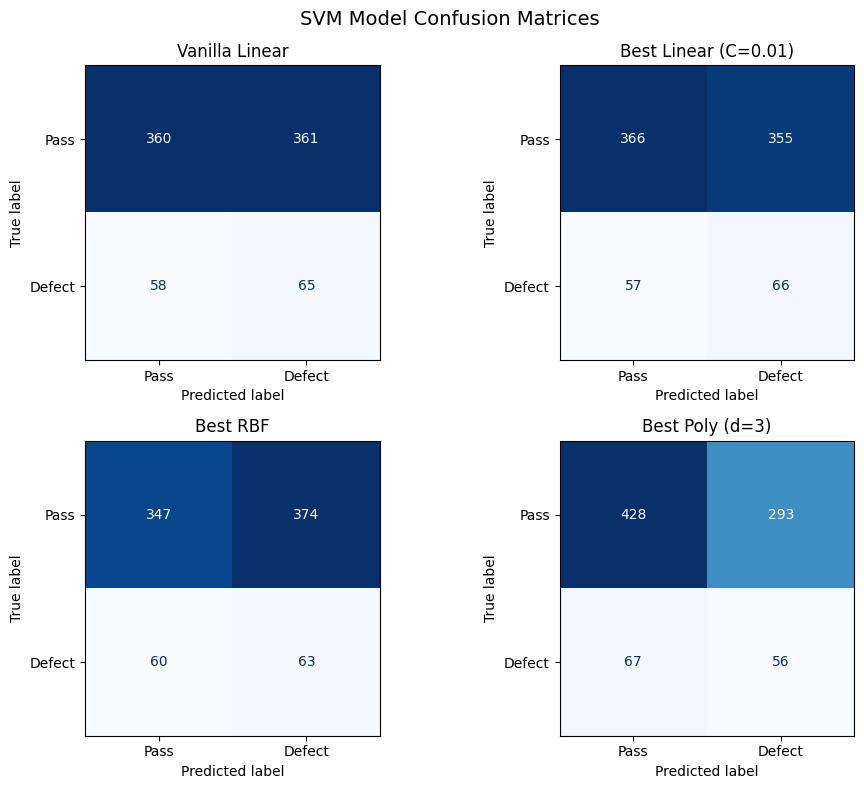

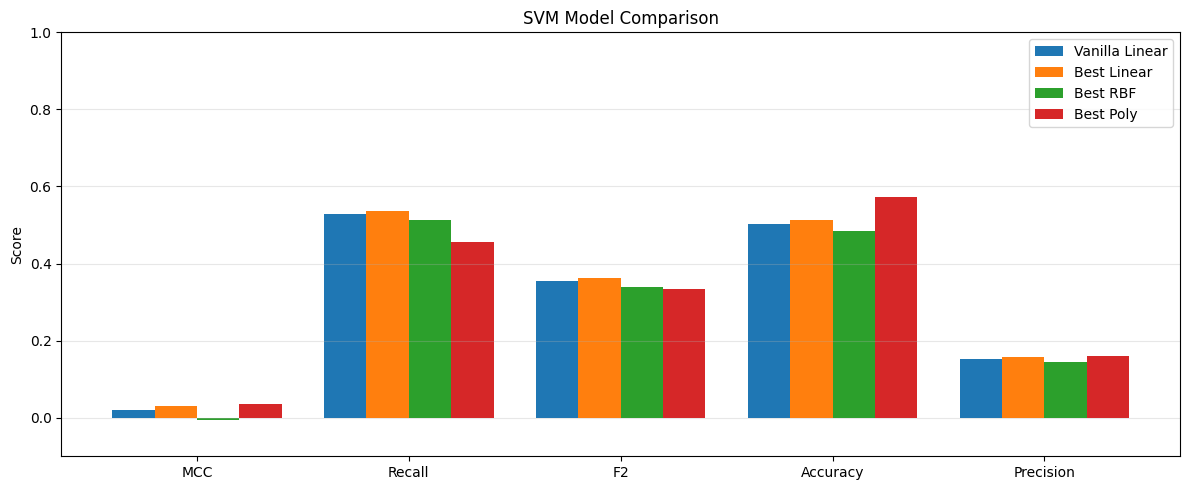

In [112]:
svm_final_comparison = pd.DataFrame({
    'Vanilla Linear': get_metrics_svm(y_test, y_pred_svm),
    f'Best Linear (C={best_linear["C"]:.2f})': get_metrics_svm(y_test, pred_linear),
    f'Best RBF': get_metrics_svm(y_test, pred_rbf),
    f'Best Poly (d={int(best_poly["Degree"])})': get_metrics_svm(y_test, pred_poly)
}).T

print("SVM Model Comparison:")
print(svm_final_comparison.round(4).to_string())
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

predictions = [y_pred_svm, pred_linear, pred_rbf, pred_poly]
titles = ['Vanilla Linear', f'Best Linear (C={best_linear["C"]:.2f})', 'Best RBF', f'Best Poly (d={int(best_poly["Degree"])})']

for ax, pred, title in zip(axes, predictions, titles):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(title)
    ax.grid(False)

plt.suptitle('SVM Model Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()
metrics = ['MCC', 'Recall', 'F2', 'Accuracy', 'Precision']
x_pos = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - 1.5*width, svm_final_comparison.iloc[0], width, label='Vanilla Linear')
ax.bar(x_pos - 0.5*width, svm_final_comparison.iloc[1], width, label='Best Linear')
ax.bar(x_pos + 0.5*width, svm_final_comparison.iloc[2], width, label='Best RBF')
ax.bar(x_pos + 1.5*width, svm_final_comparison.iloc[3], width, label='Best Poly')

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('SVM Model Comparison')
ax.legend()
ax.set_ylim(-0.1, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
